In [14]:
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 
import os
from astropy.constants import c
from astropy import constants as const
import astropy.units as u
from scipy import special
from scipy.special import wofz
from scipy.signal import find_peaks
from scipy.interpolate import interp1d


C_IV_K = 1548.187e-8  # cm
C_IV_H = 1550.772e-8  # cm

CIV_nu_K = 1.936410e15
CIV_nu_H = 1.933182e15

C_IV_K_A = 1548.187  # cm
C_IV_H_A = 1550.772  # cm


cc = c.to(u.cm / u.s).value  # cm/s
cc_k = c.to(u.km / u.s).value #km / s
v_th_CIV = 11.7673179819719e5  # cm/s


emu_e = 1.602e-19*3e9 # Electric charge : emu
m_e = 9.10938356e-28 # Electron Mass : g 
C_IV_gamma_H = 2.64e+8 
C_IV_gamma_K = 2.65e+8 
C_IV_f12_H   = 0.0952e0
C_IV_f12_K   = 0.190e0


c_cms = 2.99792458e10  # Light Speed : cm/s


NN = int(5e4)
C_IV_N = np.linspace(1e12, 1e17, NN)
nu = np.linspace(1.8e15,2.0e15,10000) # frequency

rr = np.arange(12, 18, 1)
atom = [13,20,32,50,79]
rr_reshaped = rr.reshape(-1, 1)
total_N_c = 10**rr_reshaped * atom / 10
total_N_c = total_N_c.flatten()

Del_V = (CIV_nu_K/ nu -1)*cc_k
V_c = 250 # km/s ()
Vsep = abs(( C_IV_H - C_IV_K) / C_IV_K)*cc_k



def nos_tau_less_one(NCIV,Random_motion):
    sigma0_K = (np.sqrt(np.pi)*emu_e**2)  *C_IV_f12_K / (m_e*c_cms) 
    factor_K = sigma0_K * c_cms / CIV_nu_K
    NoS = (2.67e13 / 11.8e5)*factor_K *(NCIV/2.67e13)*(11.8/Random_motion)
    print((2.67e13 / 11.8e5)*factor_K)
    return NoS


def calculate_order_and_value(value):
    """ 주어진 값에 대해 변환된 값과 해당 order 반환 """

    if value == 0 :
        return "000" , 0
    elif value == 1:
        return int(value * 100), 0
    elif value < 100:
        return int(value * 10), 1
    elif value < 1000:
        return int(value), 2
    else :
        return int(value / 10), 3

#combine K and H lines
def K_H_from_Combine_data_com(Line , atom_num , atom_index, vout, vemit, vran):
    out, out_order = calculate_order_and_value(vout)
    emit, emit_order = calculate_order_and_value(vemit)
    ran , ran_order = calculate_order_and_value(vran)

    path = r'/home/jin/data_CIV/N_atom{}0E+{}_Vexp{}E+0{}_Vemit{}E+0{}_tauD000E+00_Vran{}E+0{}spec_com.dat'.format(atom_num, atom_index , out, out_order, emit, emit_order, ran, ran_order)
    try:
        data = pd.read_csv(path, sep='\s+', header=None)
    except:
        print('파일을 찾을 수 없습니다.',path)


    lam = data[0].to_numpy()
    spec_tot = data[1].to_numpy()
    spec_sc = data[2].to_numpy()
   # spec_pol_tot = data[3]
   # spec_pol_scat = data[4]
    return lam , spec_tot , spec_sc



#separate K and H line
def K_H_from_Combine_data_x(Line , atom_num , atom_index, vout, vemit, vran):
    out, out_order = calculate_order_and_value(vout)
    emit, emit_order = calculate_order_and_value(vemit)
    ran , ran_order = calculate_order_and_value(vran)

    path = r'/home/jin/data_CIV/N_atom{}0E+{}_Vexp{}E+0{}_Vemit{}E+0{}_tauD000E+00_Vran{}E+0{}spec.dat'.format(atom_num, atom_index , out, out_order, emit, emit_order, ran, ran_order)
    try:
        data = pd.read_csv(path, sep='\s+', header=None)
    except:
        print('파일을 찾을 수 없습니다.',path)


    x = data[0].to_numpy()
    if Line == 'h' or Line =='H':
        lam = -  C_IV_H_A / ( (vran/cc_k)*x -1)
        spec_tot = data[2].to_numpy()
        spec_scat = data[4].to_numpy()

    elif Line == 'k' or Line =='K':
        lam = - C_IV_K_A / ( (vran/cc_k)*x -1)
        spec_tot = data[1].to_numpy()
        spec_scat = data[3].to_numpy()       

    
    return lam , spec_tot , spec_scat , x


def data_scat(Line , atom_num , atom_index, vout, vemit, vran):
    out, out_order = calculate_order_and_value(vout)
    emit, emit_order = calculate_order_and_value(vemit)
    ran , ran_order = calculate_order_and_value(vran)

    path = r'/home/jin/data_CIV/N_atom{}0E+{}_Vexp{}E+0{}_Vemit{}E+0{}_tauD000E+00_Vran{}E+0{}_f_esc.dat'.format(atom_num, atom_index , out, out_order, emit, emit_order, ran, ran_order)
    try:
        data = pd.read_csv(path, sep='\s+', header=None)
    except:
        print('파일을 찾을 수 없습니다.',path)

    if Line == 'k' or Line =='K':
        N_sct = data.iloc[0,4]

    elif Line == 'h' or Line =='H':
        N_sct = data.iloc[0,5]

    return N_sct
    


def K_H_from_Combine_data(Line , atom_num , atom_index, vout, vemit, vran):
    lam , spec_tot , spec_halo =  K_H_from_Combine_data_com(Line , atom_num , atom_index, vout, vemit, vran)
    lam_c =  (C_IV_K_A + C_IV_H_A) / 2
    if Line == 'k' or Line =='K':
        ioc = np.where(lam<=lam_c)[0]
        lam_x = lam[ioc]
        spec_tot_x = spec_tot[ioc]
        spec_halo_x  = spec_halo[ioc]

    elif Line == 'h' or Line =='H':
        ioc = np.where(lam>=lam_c)[0]
        lam_x = lam[ioc]
        spec_tot_x = spec_tot[ioc]
        spec_halo_x  = spec_halo[ioc]
    else :
        lam_x  = lam 
        spec_tot_x = spec_tot
        spec_halo_x = spec_halo

    return lam_x , spec_tot_x , spec_halo_x

lam, spec_tot , spec_halo = K_H_from_Combine_data('all',50,14,200,400,100)
# plt.plot(lam,spec_tot)
# plt.axvline(x=1549,ymin=0,ymax=2)

from scipy.signal import find_peaks

# 빛의 속도 (km/s)

import numpy as np
from scipy.interpolate import PchipInterpolator

def del_v_peaks(Line, atom_num, atom_index, vout, vemit, vran):
    lam, spec_tot, spec_scat = K_H_from_Combine_data(
        Line, atom_num, atom_index, vout, vemit, vran
    )

    if lam[0] > lam[-1]:
        sort_idx = np.argsort(lam)
        lam = lam[sort_idx]
        spec_scat = spec_scat[sort_idx]

    if Line in ['k', 'K']:
        lambda_0 = C_IV_K_A
    elif Line in ['h', 'H']:
        lambda_0 = C_IV_H_A
    else:
        raise ValueError("Invalid Line input")

    win = 5.0
    mask0 = (lam >= lambda_0 - win) & (lam <= lambda_0 + win)
    lam_use = lam[mask0]
    spec_use = spec_scat[mask0]

    lam_fine = np.linspace(lam_use.min(), lam_use.max(), 50000)
    f = PchipInterpolator(lam_use, spec_use)
    spec_fine = f(lam_fine)

    grad = np.gradient(spec_fine, lam_fine)
    sign = np.sign(grad)

    for i in range(1, len(sign)):
        if sign[i] == 0:
            sign[i] = sign[i - 1]

    peak_idx = np.where((sign[:-1] > 0) & (sign[1:] < 0))[0] + 1
    peak_lambda_all = lam_fine[peak_idx]
    peak_values_all = spec_fine[peak_idx]

    mask = peak_values_all > 10000
    peak_lambda_all2 = peak_lambda_all[mask]
    peak_values_all2 = peak_values_all[mask]

    center_idx = np.argmin(np.abs(lam_fine - lambda_0))
    center_value = spec_fine[center_idx]

    order_all = np.argsort(peak_lambda_all2)
    peak_lambda_all2 = peak_lambda_all2[order_all]
    peak_values_all2 = peak_values_all2[order_all]

    if len(peak_lambda_all2) < 2:
        return 0.0, []

    if center_value >= 0.98 * np.max(peak_values_all2):
        return 0.0, []

    max_diff = -np.inf
    best_i, best_j = 0, 1

    for i in range(len(peak_lambda_all2)):
        for j in range(i + 1, len(peak_lambda_all2)):
            diff = peak_lambda_all2[j] - peak_lambda_all2[i]
            if diff > max_diff:
                max_diff = diff
                best_i, best_j = i, j

    peak_lambda = np.array([peak_lambda_all2[best_i], peak_lambda_all2[best_j]])
    del_v = ((peak_lambda[1] - lambda_0) / lambda_0) * cc_k * 2

    return del_v, peak_lambda
    # return del_v, peak_lambda #, top_2_indices

def lam_to_vel(lam):
    vel = (lam - C_IV_K_A) * cc_k / C_IV_K_A   # km/s
    return vel


def H_voigt_fast(x, a):
    z = x + 1j*a
    return np.real(wofz(z))


def analytic_solution(Line, v_th):

    b = v_th
    sigma0 = (np.sqrt(np.pi) * emu_e**2) / (m_e * cc)

    del_nu_K = (b / cc_k) * CIV_nu_K
    del_nu_H = (b / cc_k) * CIV_nu_H

    x_K = (nu - CIV_nu_K) / del_nu_K
    x_H = (nu - CIV_nu_H) / del_nu_H

    a_K = C_IV_gamma_K / (4 * np.pi * del_nu_K)
    a_H = C_IV_gamma_H / (4 * np.pi * del_nu_H)

    K_term = (C_IV_f12_K / del_nu_K) * H_voigt_fast(x_K, a_K) / np.sqrt(np.pi)
    H_term = (C_IV_f12_H / del_nu_H) * H_voigt_fast(x_H, a_H) / np.sqrt(np.pi)

    cross_sec = sigma0 * (K_term + H_term)

    K_region = np.where((Del_V >= -V_c) & (Del_V <= V_c))
    H_region = np.where((Del_V >= Vsep - V_c) & (Del_V <= Vsep + V_c))

    delV_K, cs_K = Del_V[K_region], cross_sec[K_region]
    delV_H, cs_H = Del_V[H_region], cross_sec[H_region]

    x_kk = delV_K / (-b)
    x_hh = (delV_H - Vsep) / (-b)

    tau_profile_K = C_IV_N[:, None] * cs_K
    tau_profile_H = C_IV_N[:, None] * cs_H

    x_esc = np.zeros(len(C_IV_N))
    FWHM_tau05 = np.zeros(len(C_IV_N))

    def find_tau_crossings(x_arr, tau_arr, level):
        s = tau_arr - level
        cross_idx = np.where(np.sign(s[:-1]) * np.sign(s[1:]) < 0)[0]

        x_candidates = []
        for jj in cross_idx:
            tau_a, tau_b = tau_arr[jj], tau_arr[jj + 1]
            x_a, x_b = x_arr[jj], x_arr[jj + 1]

            if tau_b == tau_a:
                continue

            x_cross = x_a + (level - tau_a) * (x_b - x_a) / (tau_b - tau_a)
            x_candidates.append(x_cross)

        return np.array(x_candidates)

    def get_width_with_your_rule(delv_arr, tau_arr):
        peak_ii = np.argmax(tau_arr)
        peak_tau = tau_arr[peak_ii]

        if peak_tau <= 1.0:
            level = 0.5 * peak_tau
            delV_half = find_tau_crossings(delv_arr, tau_arr, level)
            if len(delV_half) >= 2:
                return (np.max(delV_half) - np.min(delV_half))
            elif len(delV_half) == 1:
                # 중심 대칭 fallback
                return 2.0 * np.abs(delV_half[0])

            else:
                # crossing이 하나도 없으면 peak 기준 대칭 fallback
                return 2.0 * np.abs(delv_arr[peak_ii]) 
        else:
            level = 1.0

            delV_half = find_tau_crossings(delv_arr, tau_arr, level)

            if len(delV_half) >= 2:
                return (np.max(delV_half) - np.min(delV_half))*1.2

            elif len(delV_half) == 1:
                # 중심 대칭 fallback
                return 2.0 * np.abs(delV_half[0])*1.2

            else:
                # crossing이 하나도 없으면 peak 기준 대칭 fallback
                return 2.0 * np.abs(delv_arr[peak_ii]) *1.2

    if Line.upper() == 'K':
        for ii in range(len(C_IV_N)):
            tau_i = tau_profile_K[ii, :]

            # tau = 1 crossing
            x_tau1 = find_tau_crossings(x_kk, tau_i, 1.0)
            if len(x_tau1) > 0:
                x_esc[ii] = np.max(x_tau1)
            else:
                pidx = np.argmax(tau_i)
                x_esc[ii] = np.abs(x_kk[pidx])

            # 사용자 정의 메커니즘 적용
            FWHM_tau05[ii] = get_width_with_your_rule(delV_K, tau_i)

        del_lam_D = (b * 1e5) / C_IV_K
        nu_0_K = cc / C_IV_K
        real_x_esc = x_esc 
        nu_esc = real_x_esc * del_lam_D + nu_0_K
        V_peak_sep = 2 * abs((nu_esc - nu_0_K) / nu_0_K) * cc / 1e5
        v_esc = x_esc * b
        N_esc = 1 / special.erfc(real_x_esc)

        return delV_K, cs_K, real_x_esc, V_peak_sep, N_esc, FWHM_tau05

    elif Line.upper() == 'H':
        for ii in range(len(C_IV_N)):
            tau_i = tau_profile_H[ii, :]

            # tau = 1 crossing
            x_tau1 = find_tau_crossings(x_hh, tau_i, 1.0)
            if len(x_tau1) > 0:
                x_esc[ii] = np.max(x_tau1)
            else:
                pidx = np.argmax(tau_i)
                x_esc[ii] = np.abs(x_hh[pidx])

            # 사용자 정의 메커니즘 적용
            FWHM_tau05[ii] = get_width_with_your_rule(delV_H, tau_i)

        del_lam_D = (b * 1e5) / C_IV_H
        nu_0_H = cc / C_IV_H
        real_x_esc = x_esc 
        nu_esc = real_x_esc * del_lam_D + nu_0_H
        V_peak_sep = 2 * abs((nu_esc - nu_0_H) / nu_0_H) * cc / 1e5
        v_esc = real_x_esc * b
        N_esc = 1 / special.erfc(real_x_esc)

        return delV_H, cs_H, real_x_esc, V_peak_sep, N_esc, FWHM_tau05



In [15]:
import numpy as np
from scipy.interpolate import PchipInterpolator

def FWHM(Line, atom_num, atom_index, vout, vemit, vran):
    lam, spec_tot, spec_halo = K_H_from_Combine_data_com(Line, atom_num, atom_index, vout, vemit, vran)

    eps = 1e-12  # 절대 0 반환 방지용 최소값

    if len(lam) == 0:
        return eps

    if lam[0] > lam[-1]:
        sort_idx = np.argsort(lam)
        lam = lam[sort_idx]
        spec_halo = spec_halo[sort_idx]

    if Line in ['h', 'H']:
        lambda_0 = C_IV_H_A
    elif Line in ['k', 'K']:
        lambda_0 = C_IV_K_A
    else:
        raise ValueError("Invalid Line input")

    win = 5.0
    mask0 = (lam >= lambda_0 - win) & (lam <= lambda_0 + win)
    lam_use = lam[mask0]
    spec_use = spec_halo[mask0]

    # window 안에 데이터가 없으면 전체 데이터라도 사용
    if len(lam_use) == 0:
        lam_use = lam.copy()
        spec_use = spec_halo.copy()

    # 그래도 점이 0개면 진짜 방법이 없으니 아주 작은 양수 반환
    if len(lam_use) == 0:
        return eps

    # 점이 1개뿐이면 local spacing을 만들 수 없으니 최소 양수 반환
    if len(lam_use) == 1:
        return eps

    # -------------------------------------------------
    # 보간
    # -------------------------------------------------
    try:
        lam_fine = np.linspace(lam_use.min(), lam_use.max(), 50000)
        f = PchipInterpolator(lam_use, spec_use)
        spec_fine = f(lam_fine)
    except Exception:
        # 보간 실패 시 원 데이터 사용
        lam_fine = lam_use.copy()
        spec_fine = spec_use.copy()

    # 안전장치
    if len(lam_fine) < 2:
        return eps

    # -------------------------------------------------
    # 공통 유틸
    # -------------------------------------------------
    def positive(v):
        v = float(abs(v))
        return v if v > 0 else eps

    def width_from_two_lam(x1, x2):
        v1 = lam_to_vel(x1)
        v2 = lam_to_vel(x2)
        return positive(v2 - v1)

    def find_crossings(x, y, level, peak_idx):
        yy = y - level

        left_x = None
        for i in range(peak_idx - 1, -1, -1):
            y1 = yy[i]
            y2 = yy[i + 1]
            if y1 == 0:
                left_x = x[i]
                break
            if y1 * y2 < 0:
                x1 = x[i]
                x2 = x[i + 1]
                left_x = x1 - y1 * (x2 - x1) / (y2 - y1)
                break

        right_x = None
        for i in range(peak_idx, len(x) - 1):
            y1 = yy[i]
            y2 = yy[i + 1]
            if y1 == 0:
                right_x = x[i]
                break
            if y1 * y2 < 0:
                x1 = x[i]
                x2 = x[i + 1]
                right_x = x1 - y1 * (x2 - x1) / (y2 - y1)
                break

        return left_x, right_x

    def gaussian_fwhm_from_logfit(x, y, peak_idx):
        # Gaussian: y = A exp(-(x-mu)^2 / (2 sigma^2))
        # ln y = a x^2 + b x + c, sigma = sqrt(-1/(2a))
        n = len(x)
        i0 = max(0, peak_idx - 8)
        i1 = min(n, peak_idx + 9)

        xx = x[i0:i1]
        yy = y[i0:i1]

        # 양수값만 사용
        mask = yy > 0
        xx = xx[mask]
        yy = yy[mask]

        if len(xx) < 3:
            return None

        try:
            coeff = np.polyfit(xx, np.log(yy), 2)
            a, b, c = coeff
            if a >= 0:
                return None
            sigma = np.sqrt(-1.0 / (2.0 * a))
            fwhm_lam = 2.0 * np.sqrt(2.0 * np.log(2.0)) * sigma

            # lambda 폭 -> velocity 폭
            mu = -b / (2.0 * a)
            x_left = mu - 0.5 * fwhm_lam
            x_right = mu + 0.5 * fwhm_lam
            return width_from_two_lam(x_left, x_right)
        except Exception:
            return None

    def moment_fwhm(x, y):
        # 마지막 fallback: 양수 가중치 기반 second moment
        yy = np.array(y, dtype=float)
        yy = yy - np.min(yy)
        yy[yy < 0] = 0

        s = np.sum(yy)
        if s <= 0:
            return None

        mu = np.sum(x * yy) / s
        var = np.sum(yy * (x - mu) ** 2) / s
        if var <= 0:
            return None

        sigma = np.sqrt(var)
        fwhm_lam = 2.0 * np.sqrt(2.0 * np.log(2.0)) * sigma
        x_left = mu - 0.5 * fwhm_lam
        x_right = mu + 0.5 * fwhm_lam
        return width_from_two_lam(x_left, x_right)

    def single_peak_fwhm(x, y, peak_idx):
        peak_val = y[peak_idx]
        if peak_val <= 0:
            # 음수/0 peak면 Gaussian fallback
            g = gaussian_fwhm_from_logfit(x, y, peak_idx)
            if g is not None:
                return positive(g)
            m = moment_fwhm(x, y)
            if m is not None:
                return positive(m)
            return eps

        HM = 0.5 * peak_val
        left_x, right_x = find_crossings(x, y, HM, peak_idx)

        # 정상 케이스: 좌우 둘 다 있으면 그대로
        if (left_x is not None) and (right_x is not None):
            return width_from_two_lam(left_x, right_x)

        # 한쪽만 있으면 대칭 가정
        peak_x = x[peak_idx]
        if (left_x is not None) and (right_x is None):
            dx = peak_x - left_x
            right_x = peak_x + dx
            return width_from_two_lam(left_x, right_x)

        if (left_x is None) and (right_x is not None):
            dx = right_x - peak_x
            left_x = peak_x - dx
            return width_from_two_lam(left_x, right_x)

        # crossing이 둘 다 없으면 Gaussian 근사
        g = gaussian_fwhm_from_logfit(x, y, peak_idx)
        if g is not None:
            return positive(g)

        # 그것도 실패하면 모멘트 기반
        m = moment_fwhm(x, y)
        if m is not None:
            return positive(m)

        # 마지막 fallback: 데이터 구간 폭
        return width_from_two_lam(x[0], x[-1])

    # -------------------------------------------------
    # peak 찾기: 기존 del_v_peaks 방식
    # -------------------------------------------------
    grad = np.gradient(spec_fine, lam_fine)
    sign = np.sign(grad)

    for i in range(1, len(sign)):
        if sign[i] == 0:
            sign[i] = sign[i - 1]

    peak_idx_all = np.where((sign[:-1] > 0) & (sign[1:] < 0))[0] + 1
    peak_lambda_all = lam_fine[peak_idx_all]
    peak_values_all = spec_fine[peak_idx_all]

    mask = peak_values_all > 10000
    peak_lambda_all2 = peak_lambda_all[mask]
    peak_values_all2 = peak_values_all[mask]

    if len(peak_lambda_all2) > 0:
        order_all = np.argsort(peak_lambda_all2)
        peak_lambda_all2 = peak_lambda_all2[order_all]
        peak_values_all2 = peak_values_all2[order_all]

    center_idx = np.argmin(np.abs(lam_fine - lambda_0))
    center_value = spec_fine[center_idx]

    # -------------------------------------------------
    # case 1) double peak이 명확하지 않으면 single peak 처리
    # -------------------------------------------------
    if len(peak_lambda_all2) < 2:
        if len(peak_idx_all) > 0:
            best_peak_idx = peak_idx_all[np.argmax(peak_values_all)]
        else:
            best_peak_idx = np.argmax(spec_fine)

        return positive(single_peak_fwhm(lam_fine, spec_fine, best_peak_idx))

    # -------------------------------------------------
    # case 2) double peak
    # -------------------------------------------------
    if center_value >= 0.98 * np.max(peak_values_all2):
        # 중앙이 너무 높아서 double-peak valley가 불명확하면
        # 그냥 strongest single peak FWHM으로 fallback
        best_peak_idx = peak_idx_all[np.argmax(peak_values_all)]
        return positive(single_peak_fwhm(lam_fine, spec_fine, best_peak_idx))

    max_diff = -np.inf
    best_i, best_j = 0, 1

    for i in range(len(peak_lambda_all2)):
        for j in range(i + 1, len(peak_lambda_all2)):
            diff = peak_lambda_all2[j] - peak_lambda_all2[i]
            if diff > max_diff:
                max_diff = diff
                best_i, best_j = i, j

    peak_lambda = np.array([peak_lambda_all2[best_i], peak_lambda_all2[best_j]])
    peak_values = np.array([peak_values_all2[best_i], peak_values_all2[best_j]])

    # 기존 로직 유지: 높은 peak 기준 half max
    HM = 0.5 * np.max(peak_values)
    y = spec_fine - HM

    cross_lam = []
    for i in range(len(lam_fine) - 1):
        y1 = y[i]
        y2 = y[i + 1]

        if y1 == 0:
            cross_lam.append(lam_fine[i])
        elif y1 * y2 < 0:
            x1 = lam_fine[i]
            x2 = lam_fine[i + 1]
            x_cross = x1 - y1 * (x2 - x1) / (y2 - y1)
            cross_lam.append(x_cross)

    cross_lam = np.array(cross_lam)

    # blue side crossing 없으면 strongest peak의 single FWHM으로 fallback
    if len(cross_lam) == 0:
        best_peak_idx = peak_idx_all[np.argmax(peak_values_all)]
        return positive(single_peak_fwhm(lam_fine, spec_fine, best_peak_idx))

    blue_cross = cross_lam[cross_lam < lambda_0]

    if len(blue_cross) == 0:
        best_peak_idx = peak_idx_all[np.argmax(peak_values_all)]
        return positive(single_peak_fwhm(lam_fine, spec_fine, best_peak_idx))

    left_lam = np.min(blue_cross)
    center_v = lam_to_vel(lambda_0)
    left_v = lam_to_vel(left_lam)

    fwhm_val = abs(left_v - center_v) * 2.0
    return positive(fwhm_val)

In [16]:
vrand = np.array([11.8, 30, 50])

for rand in vrand:
    name = str(rand).replace('.', '_')

    (globals()[f"Del_V_{name}"],
     globals()[f"cross_sec_{name}"],
     globals()[f"x_esc_{name}"],
     globals()[f"V_peak_sep_{name}"],
     globals()[f"N_esc_{name}"],
     globals()[f"FWHM_{name}"]) = analytic_solution('K', rand)

    globals()[f"tau0_{name}"] = globals()[f"cross_sec_{name}"].max() * C_IV_N

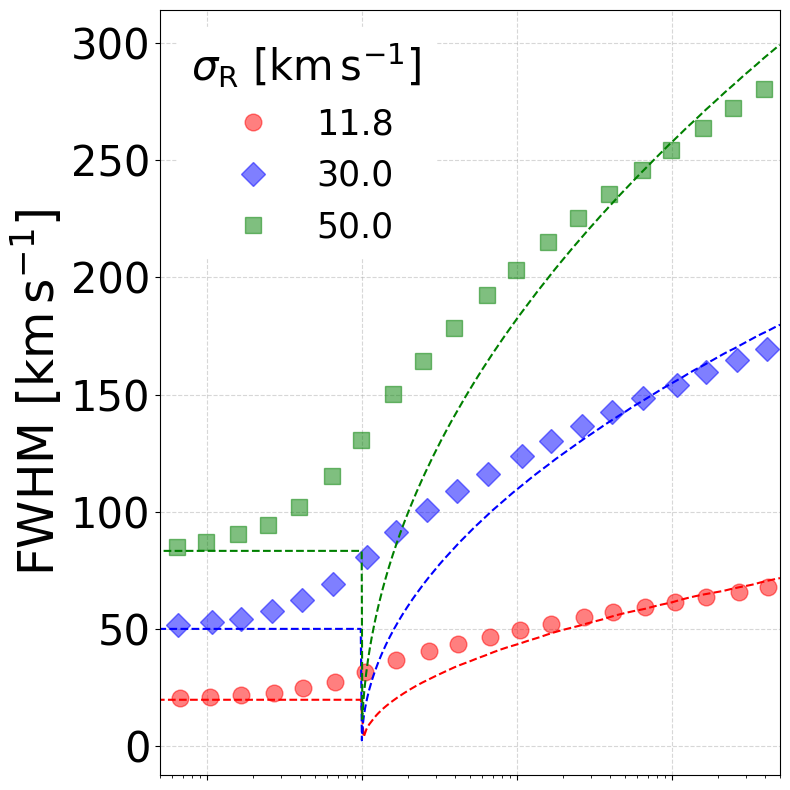

In [17]:
import numpy as np
import matplotlib.pyplot as plt

rr = np.arange(12, 17, 1)
atom_N = [13,20,32,50,79]

total_N_c = np.outer(10**rr, atom_N) / 10
total_N_c = total_N_c.flatten()

rand_nn = [11.8 , 30.0 , 50.0]
color = ['r','b','g']
shape = np.array(['o','D','s'])

# =========================

# shared x-axis figure

# =========================

fig, (ax1) = plt.subplots(1, 1, figsize=(8,8), sharex=True)

# =========================

# TOP PANEL (FWHM)

# =========================

for kk , rand in enumerate(rand_nn):

    name = str(rand).replace('.', '_')
    vv = []
    tau = np.array([])
    for ii, index in enumerate(rr):
        for jj , atom in enumerate(atom_N):
            a = FWHM('k',atom,index,0,1,rand)
            vv.append(a)
            nciv = (atom/10)*10**index
            b = ((atom/10)*10**index)*globals()[f"cross_sec_{name}"].max()
            tau = np.append(tau,b)
    # vv = np.array(vv)
    ax1.plot(globals()[f"tau0_{name}"], globals()[f"FWHM_{name}"] ,color=color[kk],linestyle='--')
    ax1.plot(tau, vv,
            marker=shape[kk], linestyle='None',
            markersize=12, color=color[kk],
            alpha=0.5, label=rf'{rand}')




ax1.set_xscale('log')
ax1.set_ylabel(r'$ \rm {FWHM} ~[\rm km \, s^{-1}]$', fontsize=35)

ax1.set_xlim(5e-2,5e2)
ax1.tick_params(labelbottom=False)  # hide top x-axis

ax1.tick_params(axis='both', labelsize=30)
ax1.grid(True, linestyle='--', alpha=0.5)

leg1 = ax1.legend(
fontsize=25,
title=r'$\sigma_{\rm R} ~ [\rm km\,s^{-1}]$',
loc='upper left',
title_fontsize=30,
frameon=True
)
leg1.get_frame().set_facecolor('white')
leg1.get_frame().set_alpha(1)
leg1.get_frame().set_edgecolor('white')

# =========================

plt.tight_layout()

# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/FWHM_ratio.pdf',bbox_inches="tight")
# plt.show()


In [18]:
def analytic_solution_NCIV(Line, v_th, NCIV):

    b = v_th
    sigma0 = (np.sqrt(np.pi) * emu_e**2) / (m_e * cc)

    del_nu_K = (b / cc_k) * CIV_nu_K
    del_nu_H = (b / cc_k) * CIV_nu_H

    x_K = (nu - CIV_nu_K) / del_nu_K
    x_H = (nu - CIV_nu_H) / del_nu_H

    a_K = C_IV_gamma_K / (4 * np.pi * del_nu_K)
    a_H = C_IV_gamma_H / (4 * np.pi * del_nu_H)

    K_term = (C_IV_f12_K / del_nu_K) * H_voigt_fast(x_K, a_K)
    H_term = (C_IV_f12_H / del_nu_H) * H_voigt_fast(x_H, a_H)

    cross_sec = sigma0 * (K_term + H_term)

    K_region = np.where((Del_V >= -V_c) & (Del_V <= V_c))
    H_region = np.where((Del_V >= Vsep - V_c) & (Del_V <= Vsep + V_c))

    delV_K, cs_K = Del_V[K_region], cross_sec[K_region]
    delV_H, cs_H = Del_V[H_region], cross_sec[H_region]

    x_kk = delV_K / (-b)
    x_hh = (delV_H - Vsep) / (-b)

    tau_profile_K = NCIV * cs_K
    tau_profile_H = NCIV * cs_H


    def find_tau_crossings(x_arr, tau_arr, level):
        s = tau_arr - level
        cross_idx = np.where(np.sign(s[:-1]) * np.sign(s[1:]) < 0)[0]

        x_candidates = []
        for jj in cross_idx:
            tau_a, tau_b = tau_arr[jj], tau_arr[jj + 1]
            x_a, x_b = x_arr[jj], x_arr[jj + 1]

            if tau_b == tau_a:
                continue

            x_cross = x_a + (level - tau_a) * (x_b - x_a) / (tau_b - tau_a)
            x_candidates.append(x_cross)

        return np.array(x_candidates)

    def get_width_with_your_rule(delv_arr, tau_arr):
        peak_ii = np.argmax(tau_arr)
        peak_tau = tau_arr[peak_ii]

        if peak_tau <= 1.0:
            level = 0.5 * peak_tau
            delV_half = find_tau_crossings(delv_arr, tau_arr, level)
            return np.max(delV_half) - np.min(delV_half)
        else:
            level = 1

            delV_half = find_tau_crossings(delv_arr, tau_arr, level)

            return (np.max(delV_half) - np.min(delV_half))*1.2

        # elif len(delV_half) == 1:
        #     # 중심 대칭 fallback
        #     return 2.0 * np.abs(delV_half[0])

        # else:
        #     # crossing이 하나도 없으면 peak 기준 대칭 fallback
        #     return 2.0 * np.abs(delv_arr[peak_ii])

    if Line.upper() == 'K':
            tau_i = tau_profile_K[:]
            x_tau1 = find_tau_crossings(x_kk, tau_i, 1.0)
            if len(x_tau1) > 0:
                x_esc = np.max(x_tau1)
            else:
                pidx = np.argmax(tau_i) 
                x_esc = np.abs(x_kk[pidx])

            # 사용자 정의 메커니즘 적용
            FWHM_tau05 = get_width_with_your_rule(delV_K, tau_i)

            del_lam_D = (b * 1e5) / C_IV_K
            nu_0_K = cc / C_IV_K
            real_x_esc = x_esc 
            nu_esc = real_x_esc * del_lam_D + nu_0_K
            V_peak_sep = 2 * abs((nu_esc - nu_0_K) / nu_0_K) * cc / 1e5
            v_esc = x_esc * b
            N_esc = 1 / special.erfc(real_x_esc)

    return delV_K, cs_K, real_x_esc, V_peak_sep, N_esc, FWHM_tau05




In [19]:
from scipy.interpolate import interp1d

half max crossings: [-140.2302972  -111.04628696  109.81687142  138.80630107]
FWHM: 279.03659826599403
half max crossings: [ 41.64907893 -41.63675599]
FWHM: 83.28583491809484
3.3503488143020346


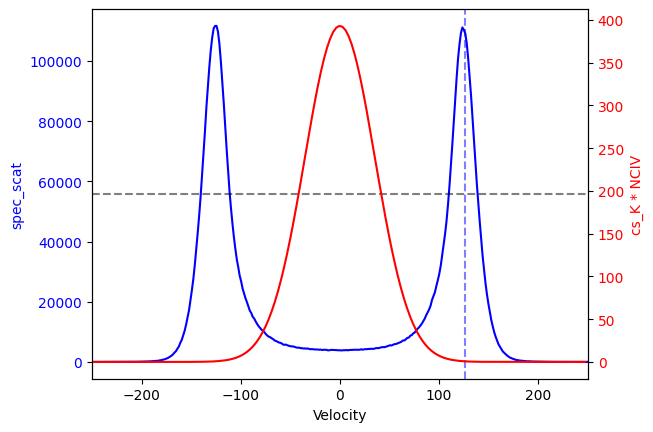

In [37]:
Line = 'K'
atom_num = 79
atom_index = 16
vout = 0
vemit = 1 
vran = 50.0
NCIV = (atom_num / 10)*10**atom_index
lam, spec_tot, spec_scat = K_H_from_Combine_data(Line , atom_num , atom_index, vout, vemit, vran)


delV_K, cs_K, real_x_esc, V_peak_sep, N_esc, FWHM_tau05 = analytic_solution_NCIV(Line, vran , NCIV)


nu_k = cc / (lam*1e-8)
Del_Vc = (CIV_nu_K/ nu_k -1)*cc_k

fig, ax1 = plt.subplots()

# 첫 번째 데이터 (왼쪽 y축)
ax1.plot(Del_Vc, spec_scat, color='blue')
ax1.set_xlabel('Velocity')
ax1.set_ylabel('spec_scat', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ii = np.argmax(spec_scat)
# print(-Del_Vc[ii])
ax1.axvline(x=-Del_Vc[ii],ymin = 0, ymax= 1,linestyle='--',color='b',alpha=0.5)


ax1.axhline(y=(spec_scat).max() / 2 ,xmin = 0, xmax= 1,linestyle='--',color='k',alpha=0.5)


half = spec_scat.max() / 2
y = spec_scat - half
x = Del_Vc

crossings = []

for i in range(len(y) - 1):
    if y[i] == 0:
        crossings.append(x[i])
    elif y[i] * y[i+1] < 0:  # 부호가 바뀌면 교차
        # 선형 보간으로 교차점 계산
        xc = x[i] + (x[i+1] - x[i]) * (-y[i]) / (y[i+1] - y[i])
        crossings.append(xc)

crossings = np.array(crossings)
print("half max crossings:", crossings)
print("FWHM:", np.abs(crossings[0] - crossings[-1]))
FWHM_spec = np.abs(crossings[0] - crossings[-1])
# print(tt)

# x 범위 통일
ax1.set_xlim(-250, 250)

# 두 번째 y축 생성
ax2 = ax1.twinx()

# 두 번째 데이터 (오른쪽 y축)
yy = cs_K * NCIV  /np.sqrt(np.pi)
ax2.plot(delV_K, yy, color='red')
aa = (yy).max() /2
# print(aa)
# ax2.axhline(y=aa ,xmin = 0, xmax= 1,linestyle='--',color='k',alpha=0.5)
ax2.set_ylabel('cs_K * NCIV', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# ax2.axhline(y=1,xmin = 0, xmax= 1)


half = aa
y = yy - half
x = delV_K

crossings = []

for i in range(len(y) - 1):
    if y[i] == 0:
        crossings.append(x[i])
    elif y[i] * y[i+1] < 0:  # 부호가 바뀌면 교차
        # 선형 보간으로 교차점 계산
        xc = x[i] + (x[i+1] - x[i]) * (-y[i]) / (y[i+1] - y[i])
        crossings.append(xc)

crossings = np.array(crossings)
print("half max crossings:", crossings)
FWHM_analytic = np.abs(crossings[0] - crossings[-1])

print("FWHM:", np.abs(crossings[0] - crossings[-1]))

nu_esc =(real_x_esc* CIV_nu_K)*(vran/cc_k) + CIV_nu_K
Vel_esc = (real_x_esc*vran)

ratio = FWHM_spec / FWHM_analytic 
print(ratio)
# ax2.axvline(x=Vel_esc,ymin = 0, ymax= 1,linestyle = '--',color ='r',alpha=0.5)
# print(Vel_esc)
plt.show()

1.4456073716320808
1.3838170306162931
1.242544107893186


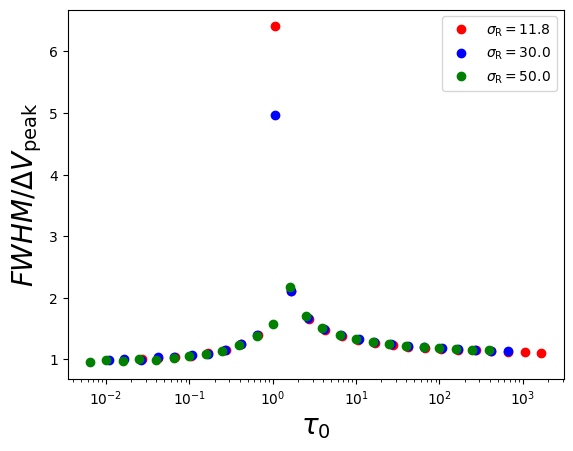

In [35]:
rr = np.arange(12, 17, 1)
atom_N = [13,20,32,50,79]

total_N_c = np.outer(10**rr, atom_N) / 10
total_N_c = total_N_c.flatten()


rand_nn = [11.8 , 30.0 , 50.0]
color = ['r','b','g']
shape = np.array(['o','D','s'])

# =========================

def FWHM_ratio(Line, atom_num, atom_index, vout, vemit, vran):
    NCIV = (atom_num/10)*10**atom_index
    lam, spec_tot, spec_scat = K_H_from_Combine_data(Line , atom_num , atom_index, vout, vemit, vran)
    delV_K, cs_K, real_x_esc, V_peak_sep, N_esc, FWHM_tau05 = analytic_solution_NCIV(Line, vran , NCIV)

    nu_k = cc / (lam*1e-8)
    Del_Vc = (CIV_nu_K/ nu_k -1)*cc_k

    y_max = (cs_K * NCIV  /np.sqrt(np.pi)).max()
    if y_max <= 1.0 :    
        half_a = y_max / 2
    else:
        half_a = 1 

    y_a = (cs_K * NCIV  /np.sqrt(np.pi)) - half_a
    x_a = delV_K

    crossings_a = []
    for i in range(len(y_a) - 1):
        if y_a[i] == 0:
            crossings.append(x_a[i])
        elif y_a[i] * y_a[i+1] < 0:  # 부호가 바뀌면 교차
            # 선형 보간으로 교차점 계산
            xc = x_a[i] + (x_a[i+1] - x_a[i]) * (-y_a[i]) / (y_a[i+1] - y_a[i])
            crossings_a.append(xc)
    FWHM_analytic = np.abs(crossings_a[0] - crossings_a[-1])

    half_s = spec_scat.max() / 2
    y_s = spec_scat  - half_s
    x_s = Del_Vc

    crossings_s = []
    for i in range(len(y_s) - 1):
        if y_s[i] == 0:
            crossings_s.append(x_s[i])
        elif y_s[i] * y_s[i+1] < 0:  # 부호가 바뀌면 교차
            xc = x_s[i] + (x_s[i+1] - x_s[i]) * (-y_s[i]) / (y_s[i+1] - y_s[i])
            crossings_s.append(xc)

    FWHM_spec = np.abs(crossings_s[0] - crossings_s[-1])
    
    ratio = FWHM_spec / FWHM_analytic 
    return FWHM_spec,FWHM_analytic ,  ratio




for ii, rand in enumerate(rand_nn):
    name = str(rand).replace('.', '_')
    vv = np.array([])
    tau = np.array([])
    FWHM_spec = np.array([])
    FWHM_analy = np.array([])
    for kk, index in enumerate(rr):  
        for jj, atom in enumerate(atom_N):
            Line = 'K'
            FWHM_s,FWHM_a, ratio = FWHM_ratio(Line, atom, index, 0, 1, rand)
            vv = np.append(vv, ratio)
            b = ((atom/10)*10**index)*globals()[f"cross_sec_{name}"].max()  
            tau = np.append(tau,b)
            FWHM_spec = np.append(FWHM_spec,FWHM_s)
            FWHM_analy = np.append(FWHM_analy,FWHM_a)
    plt.plot(tau, vv, color=color[ii], marker='o', linestyle='None', label=rf'$\sigma_{{\rm R}} = ${rand}')
    # plt.plot(tau, FWHM_spec, color=color[ii],linestyle='--',label=r'$\sigma_{\rm R} = $'+str(rand))
    # plt.plot(tau, FWHM_analy, color=color[ii],linestyle='-',label=r'$\sigma_{\rm R} = $'+str(rand))
    print(vv.mean())

plt.xscale('log')
plt.ylabel(r'$FWHM / \Delta V_{\rm peak}$',fontsize=20)
plt.xlabel(r'$\tau_0$',fontsize=20),

plt.legend()


In [22]:
a

280.4823486506198

44.018670239122415
101.15456821899191
158.98794477558388


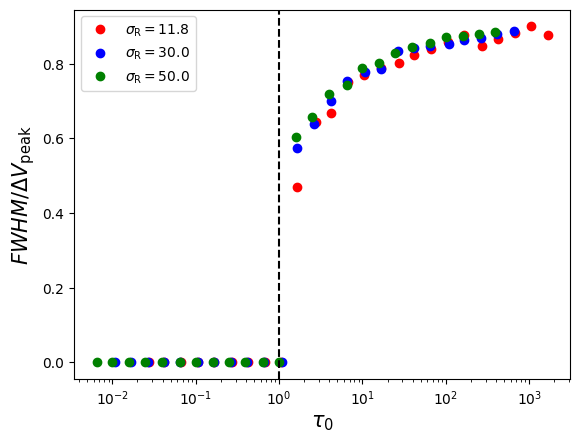

In [64]:


rr = np.arange(12, 17, 1)
atom_N = [13,20,32,50,79]

total_N_c = np.outer(10**rr, atom_N) / 10
total_N_c = total_N_c.flatten()


rand_nn = [11.8 , 30.0 , 50.0]
color = ['r','b','g']
shape = np.array(['o','D','s'])

# =========================

def FWHM_ratio(Line, atom_num, atom_index, vout, vemit, vran):

    lam, spec_tot, spec_scat = K_H_from_Combine_data(Line , atom_num , atom_index, vout, vemit, vran)
    nu_k = cc / (lam*1e-8)
    Del_Vc = (CIV_nu_K/ nu_k -1)*cc_k


    half_s = spec_scat.max() / 2
    y_s = spec_scat  - half_s
    x_s = Del_Vc

    crossings_s = []
    for i in range(len(y_s) - 1):
        if y_s[i] == 0:
            crossings_s.append(x_s[i])
        elif y_s[i] * y_s[i+1] < 0:  # 부호가 바뀌면 교차
            xc = x_s[i] + (x_s[i+1] - x_s[i]) * (-y_s[i]) / (y_s[i+1] - y_s[i])
            crossings_s.append(xc)

    FWHM_spec = np.abs(crossings_s[0] - crossings_s[-1])
    
    ratio = FWHM_spec 
    return FWHM_spec




for ii, rand in enumerate(rand_nn):
    name = str(rand).replace('.', '_')
    vv = np.array([])
    tau = np.array([])
    FWHM_spec = np.array([])
    Peak_sep_spec = np.array([])
    for kk, index in enumerate(rr):  
        for jj, atom in enumerate(atom_N):
            Line = 'K'
            FWHM_s = FWHM_ratio(Line, atom, index, 0, 1, rand)
            vv = np.append(vv, FWHM_s)
            b = ((atom/10)*10**index)*globals()[f"cross_sec_{name}"].max()  

            a , lam  = del_v_peaks('k',atom,index,0,1,rand)
            tau = np.append(tau,b)
            FWHM_spec = np.append(FWHM_spec,FWHM_s)
            Peak_sep_spec = np.append(Peak_sep_spec,a)
    plt.plot(tau, Peak_sep_spec / vv , color=color[ii],marker='o',linestyle='None',label=r'$\sigma_{\rm R} = $'+str(rand))
    print(vv.mean())

plt.xscale('log')

plt.xlabel(r'$\tau_0$',fontsize=15)
plt.ylabel(r'$FWHM / \Delta V_{\rm peak}$',fontsize=15)

plt.axvline(x=1,ymin=0,ymax=1,linestyle='--',color='k')



# xg = np.linspace(1.0, 1e2, 4000)
# yg = np.sqrt(xg)
# plt.plot(xg,yg)

plt.legend()




In [24]:
def analytic_solution_NCIV(Line, v_th, NCIV):

    b = v_th
    sigma0 = (np.sqrt(np.pi) * emu_e**2) / (m_e * cc)

    del_nu_K = (b / cc_k) * CIV_nu_K
    del_nu_H = (b / cc_k) * CIV_nu_H

    x_K = (nu - CIV_nu_K) / del_nu_K
    x_H = (nu - CIV_nu_H) / del_nu_H

    a_K = C_IV_gamma_K / (4 * np.pi * del_nu_K)
    a_H = C_IV_gamma_H / (4 * np.pi * del_nu_H)

    K_term = (C_IV_f12_K / del_nu_K) * H_voigt_fast(x_K, a_K)
    H_term = (C_IV_f12_H / del_nu_H) * H_voigt_fast(x_H, a_H)

    cross_sec = sigma0 * (K_term + H_term)

    K_region = np.where((Del_V >= -V_c) & (Del_V <= V_c))
    H_region = np.where((Del_V >= Vsep - V_c) & (Del_V <= Vsep + V_c))

    delV_K, cs_K = Del_V[K_region], cross_sec[K_region]
    delV_H, cs_H = Del_V[H_region], cross_sec[H_region]

    x_kk = delV_K / (-b)
    x_hh = (delV_H - Vsep) / (-b)

    tau_profile_K = NCIV * cs_K
    tau_profile_H = NCIV * cs_H


    def find_tau_crossings(x_arr, tau_arr, level):
        s = tau_arr - level
        cross_idx = np.where(np.sign(s[:-1]) * np.sign(s[1:]) < 0)[0]

        x_candidates = []
        for jj in cross_idx:
            tau_a, tau_b = tau_arr[jj], tau_arr[jj + 1]
            x_a, x_b = x_arr[jj], x_arr[jj + 1]

            if tau_b == tau_a:
                continue

            x_cross = x_a + (level - tau_a) * (x_b - x_a) / (tau_b - tau_a)
            x_candidates.append(x_cross)

        return np.array(x_candidates)

    def get_width_with_your_rule(delv_arr, tau_arr):
        peak_ii = np.argmax(tau_arr)
        peak_tau = tau_arr[peak_ii]

        if peak_tau <= 1.0:
            level = 0.5 * peak_tau
        else:
            level = 0.5

        delV_half = find_tau_crossings(delv_arr, tau_arr, level)

        if len(delV_half) >= 2:
            return np.max(delV_half) - np.min(delV_half)

        elif len(delV_half) == 1:
            # 중심 대칭 fallback
            return 2.0 * np.abs(delV_half[0])

        else:
            # crossing이 하나도 없으면 peak 기준 대칭 fallback
            return 2.0 * np.abs(delv_arr[peak_ii])

    if Line.upper() == 'K':
            tau_i = tau_profile_K[:]
            x_tau1 = find_tau_crossings(x_kk, tau_i, 1.0)
            if len(x_tau1) > 0:
                x_esc = np.max(x_tau1)
            else:
                pidx = np.argmax(tau_i) 
                x_esc = np.abs(x_kk[pidx])

            # 사용자 정의 메커니즘 적용
            FWHM_tau05 = get_width_with_your_rule(delV_K, tau_i)

            del_lam_D = (b * 1e5) / C_IV_K
            nu_0_K = cc / C_IV_K
            real_x_esc = x_esc 
            nu_esc = real_x_esc * del_lam_D + nu_0_K
            V_peak_sep = 2 * abs((nu_esc - nu_0_K) / nu_0_K) * cc / 1e5
            v_esc = x_esc * b
            N_esc = 1 / special.erfc(real_x_esc)

    return delV_K, cs_K, real_x_esc, V_peak_sep, N_esc, FWHM_tau05




191.02396479113116
239.43715142259285


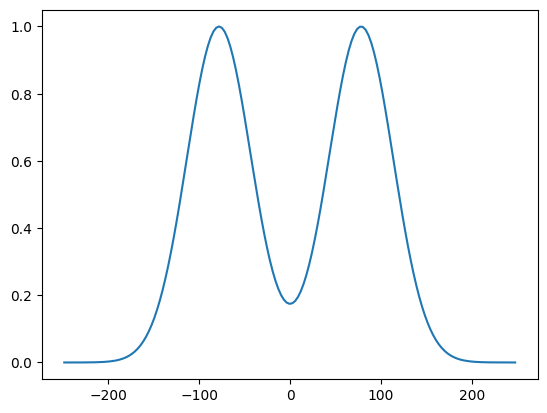

In [25]:
Line = 'K'
atom_num = 13
atom_index = 15
vout = 0
vemit = 1 
vran = 50.0
NCIV = (atom_num / 10)*10**atom_index
lam, spec_tot, spec_scat = K_H_from_Combine_data(Line , atom_num , atom_index, vout, vemit, vran)

def FWHM_spec(Line, atom_num, atom_index, vout, vemit, vran):

    lam, spec_tot, spec_scat = K_H_from_Combine_data(Line , atom_num , atom_index, vout, vemit, vran)
    nu_k = cc / (lam*1e-8)
    Del_Vc = (CIV_nu_K/ nu_k -1)*cc_k


    half_s = spec_scat.max() / 2
    y_s = spec_scat  - half_s
    x_s = Del_Vc

    crossings_s = []
    for i in range(len(y_s) - 1):
        if y_s[i] == 0:
            crossings_s.append(x_s[i])
        elif y_s[i] * y_s[i+1] < 0:  # 부호가 바뀌면 교차
            xc = x_s[i] + (x_s[i+1] - x_s[i]) * (-y_s[i]) / (y_s[i+1] - y_s[i])
            crossings_s.append(xc)

    FWHM_spec = np.abs(crossings_s[0] - crossings_s[-1])
    
    ratio = FWHM_spec 
    return FWHM_spec

delV_K, cs_K, real_x_esc, V_peak_sep, N_esc, FWHM_tau05 = analytic_solution_NCIV(Line, vran , NCIV)

FWHM_s = FWHM_spec(Line, atom_num, atom_index, vout, vemit, vran)
print(FWHM_s)

v_p = (V_peak_sep/ 2)
v_m = - (V_peak_sep/ 2)

plus_term = np.exp(- (delV_K-v_p)**2/vran**2) + np.exp(- (delV_K-v_m)**2/vran**2)

half_s = plus_term.max() / 2
y_s = plus_term  - half_s
x_s = delV_K

crossings_s = []
for i in range(len(y_s) - 1):
    if y_s[i] == 0:
        crossings_s.append(x_s[i])
    elif y_s[i] * y_s[i+1] < 0:  # 부호가 바뀌면 교차
        xc = x_s[i] + (x_s[i+1] - x_s[i]) * (-y_s[i]) / (y_s[i+1] - y_s[i])
        crossings_s.append(xc)

FWHM_an= np.abs(crossings_s[0] - crossings_s[-1])

print(FWHM_an)

plt.plot(delV_K,plus_term)

71.90606555769357
57.89412481221086


(-250.0, 250.0)

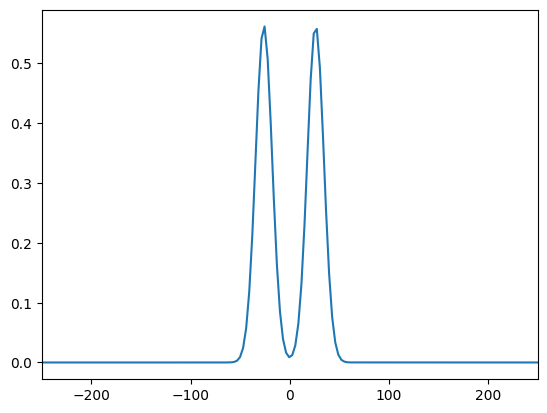

In [26]:

Line = 'K'
atom_num = 32
atom_index = 15
vout = 0
vemit = 1 
vran = 11.8
NCIV = (atom_num / 10)*10**atom_index
lam, spec_tot, spec_scat = K_H_from_Combine_data(Line , atom_num , atom_index, vout, vemit, vran)
delV_K, cs_K, real_x_esc, V_peak_sep, N_esc, FWHM_tau05 = analytic_solution_NCIV(Line, vran , NCIV)

b = vran

del_nu_K = (b / cc_k) * CIV_nu_K

sigma0 = (np.sqrt(np.pi) * emu_e**2) / (m_e * cc)

NN = int(5e4)
C_IV_N = np.linspace(1e12, 1e17, NN)
nu = np.linspace(1.8e15,2.0e15,10000) # frequency


x_esc_p = real_x_esc
x_esc_m = -real_x_esc

nu_esc_p = del_nu_K*x_esc_p + CIV_nu_K # Plus -> blue part
nu_esc_m = del_nu_K*x_esc_m + CIV_nu_K


del_nu_esc_p = (b / cc_k) * CIV_nu_K
del_nu_esc_m = (b / cc_k) * CIV_nu_K

a_esc_p = C_IV_gamma_K / (4 * np.pi * del_nu_esc_p)
a_esc_m = C_IV_gamma_K / (4 * np.pi * del_nu_esc_m)

x_p = (nu - nu_esc_p) / del_nu_esc_p
x_m = (nu - nu_esc_m) / del_nu_esc_m

p_term =  H_voigt_fast(x_p, a_esc_p)/ np.sqrt(np.pi)
m_term =  H_voigt_fast(x_m, a_esc_m)/ np.sqrt(np.pi)

total = p_term + m_term

Del_V = (CIV_nu_K/ nu -1)*cc_k

plt.plot(Del_V,total)

half_s = total.max() / 2
y_s = total  - half_s
x_s = Del_V

crossings_s = []
for i in range(len(y_s) - 1):
    if y_s[i] == 0:
        crossings_s.append(x_s[i])
    elif y_s[i] * y_s[i+1] < 0:  # 부호가 바뀌면 교차
        xc = x_s[i] + (x_s[i+1] - x_s[i]) * (-y_s[i]) / (y_s[i+1] - y_s[i])
        crossings_s.append(xc)

FWHM_an= np.abs(crossings_s[0] - crossings_s[-1])

print(FWHM_an)


FWHM_s = FWHM_spec(Line, atom_num, atom_index, vout, vemit, vran)
print(FWHM_s)



plt.xlim(-250,250)

